# Authors:
Juan Alejandro Ramon Ortega (s6470173)
Erika Saiz (s5880734)
Dániel Dávid (s6415997)

# Part I — Dimensionality Reduction

## 1. Load and inspect the dataset


In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


wine = load_wine()

dimensions = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_classes = pd.Series(wine.target, name="class")

print(dimensions.shape)               #(samples, features)
print(wine.target_names)              #the class names
print(wine_classes.value_counts())    #samples per class
print(dimensions.head())


(178, 13)
['class_0' 'class_1' 'class_2']
class
1    71
0    59
2    48
Name: count, dtype: int64
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39         

1. There are $178$ samples, as can be seen from the first value of the shape of $wine.data$. There are 178 rows, and reach row corresponds to one sample.
2. Each sample contains $13$ features, as can be seen from the second value of the shape of $wine.data$. There are 13 columns, and each column corresponds to one feature.
3. There are $3$ classes, which we can get by printing $wine.target\_names$.
4. No, the features are not measured on the same scale. For example, alcohol is measured by the percentage of the volume of ethanol in the wine, while proline is measured by miligrams per liter.


## 2. Standardize the features

In [10]:
#standardization
scaler = StandardScaler()
wine.data= scaler.fit_transform(wine.data)

Standardization is particularly important here because the features are measured on very different scales (for example, proline reaches values above 1000, while hue stays around 1). PCA looks for the directions of maximum variance, so without standardization the features with large variance would dominate the principal components, regardless of how informative they are.

## 3. Apply PCA

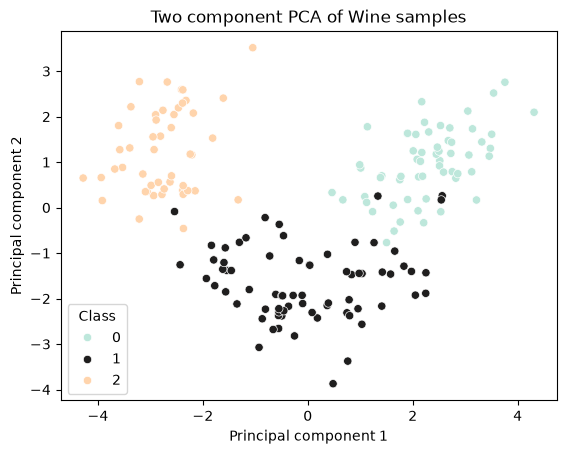

array([[ 3.31675081,  1.44346263],
       [ 2.20946492, -0.33339289],
       [ 2.51674015,  1.0311513 ],
       [ 3.75706561,  2.75637191],
       [ 1.00890849,  0.86983082],
       [ 3.05025392,  2.12240111],
       [ 2.44908967,  1.17485013],
       [ 2.05943687,  1.60896307],
       [ 2.5108743 ,  0.91807096],
       [ 2.75362819,  0.78943767],
       [ 3.47973668,  1.30233324],
       [ 1.7547529 ,  0.61197723],
       [ 2.11346234,  0.67570634],
       [ 3.45815682,  1.13062988],
       [ 4.31278391,  2.09597558],
       [ 2.3051882 ,  1.66255173],
       [ 2.17195527,  2.32730534],
       [ 1.89897118,  1.63136888],
       [ 3.54198508,  2.51834367],
       [ 2.0845222 ,  1.06113799],
       [ 3.12440254,  0.78689711],
       [ 1.08657007,  0.24174355],
       [ 2.53522408, -0.09184062],
       [ 1.64498834, -0.51627893],
       [ 1.76157587, -0.31714893],
       [ 0.9900791 ,  0.94066734],
       [ 1.77527763,  0.68617513],
       [ 1.23542396, -0.08980704],
       [ 2.18840633,

In [28]:
#PCA

def do_pca(data, components:int = 2, is_plot:bool = False, target = None, exp_variance:bool = False):
    pca_model = PCA(n_components=components, random_state= 100)
    pca_data= pca_model.fit(data)
    reduced_data= pca_data.transform(data)
    if is_plot:
        sns.scatterplot(x = reduced_data[:,0], y = reduced_data[:,1], hue = target, palette="icefire")
        plt.xlabel("Principal component 1")
        plt.ylabel("Principal component 2")
        plt.title("Two component PCA of Wine samples")
        plt.legend(title = "Class")
        plt.show()

    if exp_variance:
        return pca_data.explained_variance_ratio_
    return reduced_data
do_pca(wine.data, components= 2, is_plot= True, target = wine.target)

We made a function which performs PCA using sklearn's PCA method. We first fit the model with the wine data, and then transform it seperately. This is so we can get the attributes of both the PCA model, and also ge the dimension reduced data. Inside the function, we make the scatterplot of the individual samples which uses the first two principal components as the two axes, and colours them by the actual classes.


1. Yes, we can easily distinguish them, because there is clear separation between all three classes with very little overlapping, only a small amount between classes 0 and 1, and an even smaller amount between classes 1 and 2.
2. Class 2 is more easily separated from the others, while class 1 and class 0 have slightly more overlap.
3. Each point represents a projection from the transformed dataset $\bar{X}$ onto the two principal component’s eigenvectors.
4. Because we are only using two principal components, any fraction of the variance explained by only other components is lost. Essentially, it is only the variance in two dimensions.

## 4. Explained variance

The variance explained by the first two principal components are: [0.36198848 0.1920749 ]
Variance until explained up to and including 0th component: 0.36198848099926334
Variance until explained up to and including 1th component: 0.5540633835693529
Variance until explained up to and including 2th component: 0.6652996889318527
Variance until explained up to and including 3th component: 0.735989990758993
Variance until explained up to and including 4th component: 0.8016229275554789
Variance until explained up to and including 5th component: 0.8509811607477046
Variance until explained up to and including 6th component: 0.8933679539739378
Variance until explained up to and including 7th component: 0.9201754434577264
Variance until explained up to and including 8th component: 0.9423969775056236
Variance until explained up to and including 9th component: 0.9616971684450644
Variance until explained up to and including 10th component: 0.9790655253449635
Variance until explained up to and inclu

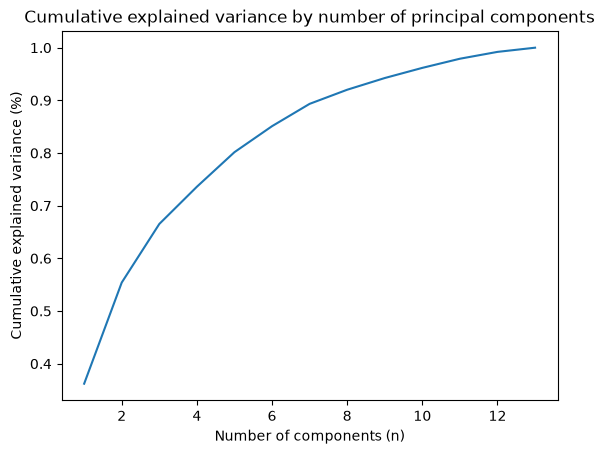

[np.float64(0.36198848099926334),
 np.float64(0.5540633835693529),
 np.float64(0.6652996889318527),
 np.float64(0.735989990758993),
 np.float64(0.8016229275554789),
 np.float64(0.8509811607477046),
 np.float64(0.8933679539739378),
 np.float64(0.9201754434577264),
 np.float64(0.9423969775056236),
 np.float64(0.9616971684450644),
 np.float64(0.9790655253449635),
 np.float64(0.9920478511010057),
 np.float64(1.0000000000000002)]

In [18]:
print(f"The variance explained by the first two principal components are: {do_pca(wine.data, components= 2, exp_variance= True)}")
def explained_variance_sum(list_var, is_verbose:bool = False, is_plot:bool = False) -> list[float]:
    cumulative_sums = []
    sum = 0
    for i in range(len(list_var)):
        sum += list_var[i]
        cumulative_sums.append(sum)
        if is_verbose:
            print(f"Variance until explained up to and including {i}th component: {sum}")

    if is_plot:
        sns.lineplot(x = [i for i in range(1, 14)], y = cumulative_sums)
        plt.xlabel("Number of components (n)")
        plt.ylabel("Cumulative explained variance (%)")
        plt.title("Cumulative explained variance by number of principal components")
        plt.show()
    return cumulative_sums

explained_variance_sum(do_pca(wine.data, components= 13, exp_variance= True), is_verbose= True, is_plot= True)

1. The amount of variance explained by the first component is 36.2%, and the by the second 19.2%, which in total is 55.4%.
2. We made a function which takes in a list of explained variances (which the fitted PCA model already provides with the $explained\_variance\_ratio\_$ attribute), and stores and optionally prints the cumulative sums of the explained variances. Thus, we can see that we reach 80% explained variance with 4 components, 80.2% to be exact.
3. With the same function, wen can see that we reach 90% with 7 components, although 6 is almost there as well.
4. The main reasons for using dimensionality reduction despite the loss in explained variance include data visualization, as 2-3 dimensions are required to do so, data preprocessing, where we reduce the dimensionality to a manageable number, and the computational tractability. Not only does it decrease model complexity, it can actually increase generalization, due to only including the most relevant information from the data.